# روش 
### used model is a classic classifier: LinearDiscriminantAnalysis (LDA)

In [1]:
# BUILD 16x16 READOUT NOISE MATRIX FROM REAL IQ DATA
# ===========================================================
# Input:
#   16 files:
#       0000.txt ... 1111.txt
# File structure:
#   - 4 lines per file
#   - each line = one qubit
#   - each line = 1000 complex IQ samples
# Output
#   1) Single-qubit assignment matrices
#   2) Full 16x16 readout noise matrix
#   3) Heatmap visualization
#   4) Saved numpy files
# ============================================================
# REAL READOUT NOISE MATRIX EXTRACTION
# WITH TRAIN / TEST SEPARATION
# ============================================================
import os,glob
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
# ============================================================
# CONFIG
DATA_DIR = "./quadrature_data_4qubits"
NUM_QUBITS = 4
NUM_STATES = 16
SHOTS_PER_FILE = 1000
RANDOM_SEED = 42
SAVE_DIR = "./noise_matrix_results"
os.makedirs(SAVE_DIR, exist_ok=True)
# ============================================================
# PARSE COMPLEX
def parse_complex_string(s):
    s = s.strip()
    if s.startswith("(") and s.endswith(")"):
        s = s[1:-1]
    return complex(s)
# ============================================================
# LOAD SINGLE FILE
def load_single_file(file_path):
    with open(file_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    if len(lines) != 4:
        raise ValueError(f"{file_path}: expected 4 lines")
    qubit_arrays = []
    for line in lines:
        tokens = line.split()
        vals = [parse_complex_string(tok) for tok in tokens]
        arr = np.array(vals, dtype=np.complex128)
        if arr.size != SHOTS_PER_FILE:
            raise ValueError(
                f"{file_path}: expected {SHOTS_PER_FILE} samples")
        qubit_arrays.append(arr)
    return np.stack(qubit_arrays, axis=0)
# ============================================================
# FILE NAME -> LABEL
def bits_from_filename(filename):
    base = os.path.splitext( os.path.basename(filename) )[0]
    bits = [int(b) for b in base[::-1]]
    return np.array(bits, dtype=int)
# ============================================================
# BITS <-> INTEGER
def bits_to_int(bits):
    q1, q2, q3, q4 = bits
    return ( q1+ 2*q2 + 4*q3 + 8*q4 )
def int_to_bits(x):
    return np.array([
        (x >> 0) & 1,
        (x >> 1) & 1,
        (x >> 2) & 1,
        (x >> 3) & 1,])
# ============================================================
# LOAD COMPLETE DATASET
def load_all_data():
    pattern = os.path.join( DATA_DIR,"[01][01][01][01].txt"  )
    file_paths = glob.glob(pattern)
    file_paths = sorted(file_paths,key=lambda fp: int(os.path.splitext(os.path.basename(fp)
            )[0],  2) )
    all_X, all_y = [], []
    for fp in file_paths:
        print(f"Loading {os.path.basename(fp)}")
        data = load_single_file(fp)
        labels = bits_from_filename(fp)
        # (4,1000) -> (1000,4)
        X_block = data.T
        y_block = np.tile(
            labels,
            (SHOTS_PER_FILE,1) )
        all_X.append(X_block)
        all_y.append(y_block)
    X = np.vstack(all_X)
    y = np.vstack(all_y)
    print("\nFinal dataset shape:")
    print("X:", X.shape)
    print("y:", y.shape)
    return X, y
# ============================================================
# VISUALIZE IQ CLOUDS
def plot_qubit_iq_clouds(X, y, qubit_index):
    z = X[:, qubit_index]
    mask0 = y[:, qubit_index] == 0
    mask1 = y[:, qubit_index] == 1
    z0 , z1 = z[mask0], z[mask1]
    plt.figure(figsize=(5,5))
    plt.scatter(z0.real,z0.imag,s=8,alpha=0.4,label="State 0" )
    plt.scatter( z1.real, z1.imag, s=8, alpha=0.4, label="State 1" )
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.title(f"Qubit {qubit_index+1} IQ Clouds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
# ============================================================
# TRAIN CLASSIFIER FOR ONE QUBIT
def train_single_qubit_classifier(   # P(m_i​∣p_i​)
    X, y, qubit_index,classifier_type = "LDA", 
     reg_param = 0.3,test_size=0.2):
    print("================================================")
    print(f"QUBIT {qubit_index+1}")
    z = X[:, qubit_index]
    features = np.column_stack([z.real, z.imag])
    labels = y[:, qubit_index]
    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=test_size,
        random_state=RANDOM_SEED, stratify=labels )
    # print("Train size:", X_train.shape[0],"Test size :", X_test.shape[0])
    # print("Test size :", X_test.shape[0])
    # ------------------------------------
    # Scaling (برای QDA مفید است)
    # ------------------------------------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    # ------------------------------------
    # Classifier
    # ------------------------------------
    if classifier_type == "LDA":
        clf = LinearDiscriminantAnalysis()
    elif classifier_type == "QDA":
        clf = QuadraticDiscriminantAnalysis(
            reg_param=reg_param)
    else:
        raise ValueError("Unknown classifier")
    # TRAIN
    # clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_s, y_train)
    # clf.fit(X_train, y_train)
    # --------------------------------------------------------
    # TEST PREDICTION
    y_pred = clf.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy = {acc:.6f}")
    # --------------------------------------------------------
    # ASSIGNMENT MATRIX
    A = confusion_matrix( y_test, y_pred,labels=[0,1], normalize="true"
    )   # A_ij = P(measured=j | prepared=i) Qiskit-compatible row-stochastic matrix
    print("Single-Qubit Assignment Matrix:")
    print(A)
    np.savetxt( os.path.join(
                SAVE_DIR, f"assignment_matrix_q{qubit_index+1}.txt" ), A )
    return clf, scaler, A
# ============================================================
# TRAIN ALL CLASSIFIERS for 4 qubits
def train_all_classifiers(X, y,
            classifier_type="LDA",reg_param=0.3):
    classifiers = []
    scalers = []
    assignment_matrices = []
    for q in range(NUM_QUBITS):
        clf,scaler, A = train_single_qubit_classifier( X, y, q,
            classifier_type=classifier_type, reg_param=reg_param)
        classifiers.append(clf)
        scalers.append(scaler)
        assignment_matrices.append(A)
    return classifiers, scalers, assignment_matrices
# ============================================================
# PREDICT FULL DATASET
def predict_full_dataset(X, classifiers, scalers):
    N = X.shape[0]
    y_pred = np.zeros((N, NUM_QUBITS), dtype=int)
    for q in range(NUM_QUBITS):
        z = X[:, q]
        features = np.column_stack([z.real,z.imag])
        features_s = scalers[q].transform(features)
        pred = classifiers[q].predict(features_s)
        y_pred[:, q] = pred
    return y_pred
# ============================================================
# BUILD 16x16 NOISE MATRIX
def build_noise_matrix(y_true, y_pred): 
    # Qiskit convention:
    # M[i,j] = P(measured=j | prepared=i)
    M = np.zeros((16,16))
    for prep_state in range(16):
        prep_bits = int_to_bits(prep_state)
        mask = np.all(y_true == prep_bits, axis=1)
        subset = y_pred[mask]
        total = subset.shape[0]
        for bits in subset:
            meas_state = bits_to_int(bits)
            M[prep_state, meas_state] += 1
        M[prep_state, :] /= total
    return M
# ============================================================
# CHECK MATRIX VALIDITY
def validate_noise_matrix(M):
    # Qiskit convention:
    # rows = prepared states
    # cols = measured states
    # therefore:
    # sum over columns for each row = 1
    print("VALIDATION")
    print("================================================")
    # col_sums = M.sum(axis=0)
    # print("\nColumn sums:\n")
    # print(col_sums)
    row_sums = M.sum(axis=1)
    print("Row sums:")
    print(row_sums)

    diag = np.diag(M)
    print("Diagonal elements:")
    print(diag)
    print("Average diagonal fidelity:")
    print(np.mean(diag))
# ============================================================
# PLOT HEATMAP
def plot_noise_matrix(M):
    plt.figure(figsize=(5,4))
    plt.imshow(M, origin="lower")
    plt.colorbar(label="Probability")
    labels = [ format(i, "04b") for i in range(16)  ]
    plt.xticks(range(16), labels, rotation=90)
    plt.yticks(range(16), labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title("16x16 Readout Noise Matrix")
    plt.tight_layout()
    out_path = os.path.join( SAVE_DIR, "noise_matrix_heatmap.png"  )
    plt.savefig(out_path, dpi=300)
    plt.show()
# SAVE MATRIX
# ============================================================
def save_noise_matrix(M):
    np.savetxt(os.path.join(
            SAVE_DIR,"noise_matrix_16x16.txt"), M)
    np.savetxt(os.path.join(SAVE_DIR,"noise_matrix_16x16.txt"
        ),M,fmt="%.8f"  )

In [3]:
# ============================================================
# OVERLAY IQ CLOUDS FOR MULTIPLE 4-QUBIT STATES
# ============================================================

def plot_fourqubit_state_overlay(X,y,target_states=("0000", "0001"),
    qubits_to_plot=None,max_points=1000, alpha=0.35):
    """ Overlay IQ clouds for multiple 4-qubit basis states.
    Parameters
    ----------
    X : ndarray
        IQ dataset, shape = (N, 4)
    y : ndarray
        Labels, shape = (N, 4)
    target_states : tuple/list
        Example:
            ("0000", "0001")
    qubits_to_plot : list or None
        Example:
            [0,1]
        If None -> plot all 4 qubits
    max_points : int
        Maximum samples per state
    alpha : float
        Scatter transparency
    """
    # --------------------------------------------------------
    # which qubits to plot
    if qubits_to_plot is None:
        qubits_to_plot = [0,1,2,3]
    n_qubits_plot = len(qubits_to_plot)
    # --------------------------------------------------------
    # subplot layout
    fig, axes = plt.subplots(
        1,n_qubits_plot,figsize=(5*n_qubits_plot, 4))
    if n_qubits_plot == 1:
        axes = [axes]
    # --------------------------------------------------------
    # colors
    colors = ["tab:blue","tab:red","tab:green",
              "tab:orange","tab:purple","tab:brown" ]
    # --------------------------------------------------------
    # loop over states
    for state_idx, target_state in enumerate(target_states):
        target_bits = np.array([int(b) for b in target_state[::-1]],
                                           dtype=int)
        mask = np.all(y == target_bits, axis=1)
        X_sel = X[mask]
        if len(X_sel) == 0:
            print(f"No samples for {target_state}")
            continue
        # optional subsampling
        if len(X_sel) > max_points:
            idx = np.random.choice(
                len(X_sel),size=max_points,replace=False)
            X_sel = X_sel[idx]
        # ----------------------------------------------------
        # plot selected qubits
        for ax_idx, q in enumerate(qubits_to_plot):
            z = X_sel[:, q]
            axes[ax_idx].scatter(
                z.real,z.imag,
                s=8,alpha=alpha,
                color=colors[state_idx % len(colors)],
                label=target_state)
    # --------------------------------------------------------
    # cosmetics
    for ax_idx, q in enumerate(qubits_to_plot):
        axes[ax_idx].set_title(
            f"Qubit {q+1}" )
        axes[ax_idx].set_xlabel("I")
        axes[ax_idx].set_ylabel("Q")
        axes[ax_idx].grid(True)
        axes[ax_idx].legend()
    plt.suptitle(
        "Overlay IQ Clouds for Multiple 4-Qubit States",
        fontsize=14)
    plt.tight_layout()
    plt.show()

## WORKFLOW

In [4]:
# STEP 1
# Load data
X, y = load_all_data()

Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

Final dataset shape:
X: (16000, 4)
y: (16000, 4)


In [6]:
X[0]
y[0]


array([0, 0, 0, 0])

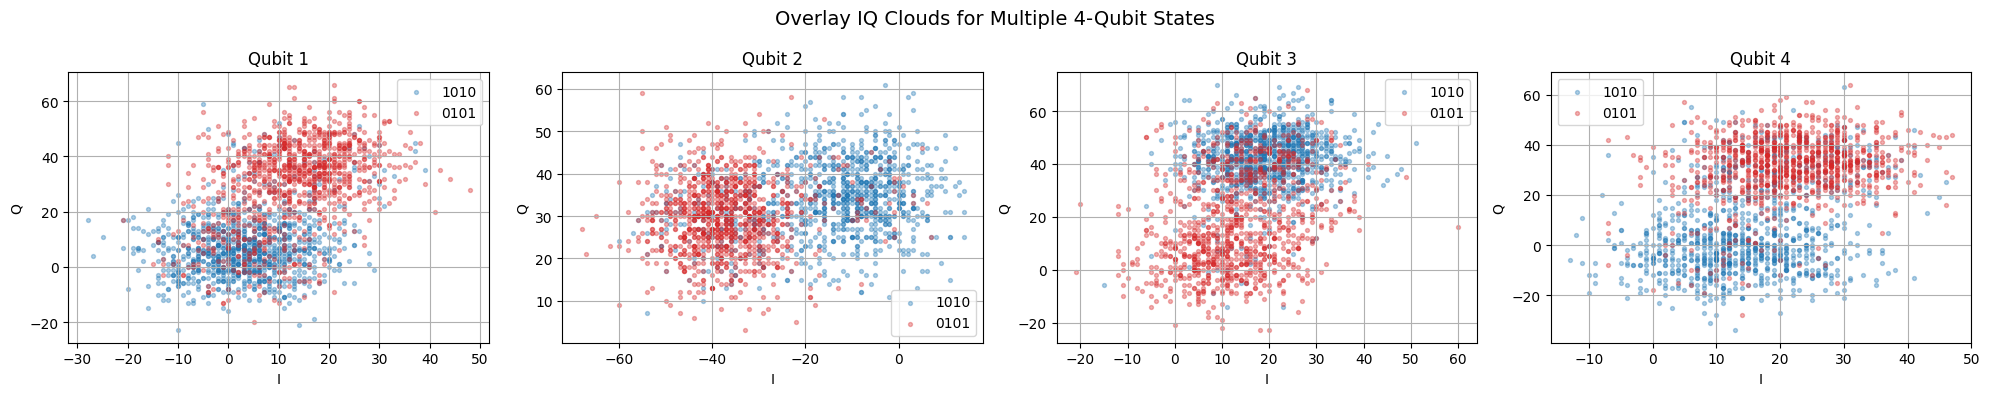

In [7]:
plot_fourqubit_state_overlay(X,y, target_states=("1010", "0101"))

In [5]:
# X[0]
y[15000]

array([1, 1, 1, 1])

In [8]:
QDA_REG_PARAM = 0.3
# CLASSIFIER_TYPE = "QDA"

CLASSIFIER_TYPE = "LDA"

classifiers, scalers, assignment_matrices = \
    train_all_classifiers(X, y,
        classifier_type=CLASSIFIER_TYPE,
        reg_param=QDA_REG_PARAM)
y_pred = predict_full_dataset(X,classifiers,scalers)

QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625 0.72375]]
QUBIT 4
Test Accuracy = 0.820312
Single-Qubit Assignment Matrix:
[[0.891875 0.108125]
 [0.25125  0.74875 ]]


In [7]:
noise_matrix = build_noise_matrix(y, y_pred)

fidelity = np.mean(np.diag(noise_matrix))
print(f"\nAverage assignment fidelity = {fidelity:.6f}")


Average assignment fidelity = 0.384875


In [8]:
y_pred = predict_full_dataset(X, classifiers, scalers)
M = build_noise_matrix( y_true=y, y_pred=y_pred)

In [9]:
validate_noise_matrix(M)

VALIDATION
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Diagonal elements:
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]
Average diagonal fidelity:
0.38487499999999997


In [29]:
save_noise_matrix(M)

In [10]:
# Compare 2 models
def run_noise_extraction(classifier_type="LDA", reg_param=0.30):
    classifiers, scalers, _ = \
        train_all_classifiers( X, y,
            classifier_type=classifier_type,
            reg_param=reg_param )
    y_pred = predict_full_dataset(
        X, classifiers, scalers)
    M = build_noise_matrix(y, y_pred)
    validate_noise_matrix(M)
    return M

In [11]:
M_LDA = run_noise_extraction(classifier_type="LDA")
M_QDA = run_noise_extraction(classifier_type="QDA",reg_param=0.30)
print(np.mean(np.diag(M_LDA)))
print(np.mean(np.diag(M_QDA)))

print(np.linalg.norm(M_LDA - M_QDA))
print(np.max(np.abs(M_LDA - M_QDA)))

QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625 0.72375]]
QUBIT 4
Test Accuracy = 0.820312
Single-Qubit Assignment Matrix:
[[0.891875 0.108125]
 [0.25125  0.74875 ]]
VALIDATION
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Diagonal elements:
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]
Average diagonal fidelity:
0.38487499999999997
QUBIT 1
Test Accuracy = 0.710313
Single-Qubit Assignment Matrix:
[[0.838125 0.161875]
 [0.4175   0.5825  ]]
QUBIT 2
Test Accuracy = 0.822187
Single-Qubit Assignment Matrix:
[[0.886875 0.113125]
 [0.2425   0.7575  ]]
QUBIT 3
Test Accuracy = 0.801875
Single-Qubit Assignment Matrix:
[[0.898125 0.101875]
 [0.294375 0.705625]]
QUBIT 4
Test

In [ ]:
# the above ourput shows a very small change between 
# QDA and LDA so we only choose LDA
# LDA is ok for start and is more stable

In [48]:
# for each qubit
# Visualize IQ clouds
# Example:
# plot_qubit_iq_clouds(X, y, qubit_index=0)

In [12]:
# STEP 3
# Train classifiers
classifiers,scalers, assignment_matrices = train_all_classifiers(X, y,
                    classifier_type = "LDA",reg_param=0.3)

QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625 0.72375]]
QUBIT 4
Test Accuracy = 0.820312
Single-Qubit Assignment Matrix:
[[0.891875 0.108125]
 [0.25125  0.74875 ]]


In [13]:
# STEP 4
# Predict all shots
y_pred = predict_full_dataset(X, classifiers, scalers)
# STEP 5
# Build full noise matrix
noise_matrix = build_noise_matrix(y, y_pred)
fidelity = np.mean(np.diag(noise_matrix))
print(f"\nAverage assignment fidelity = {fidelity:.6f}")


Average assignment fidelity = 0.384875


In [14]:
print(noise_matrix )

[[0.626 0.126 0.059 0.008 0.066 0.009 0.008 0.001 0.063 0.018 0.008 0.001
  0.003 0.002 0.001 0.001]
 [0.278 0.414 0.032 0.056 0.043 0.063 0.003 0.007 0.03  0.05  0.005 0.006
  0.003 0.008 0.001 0.001]
 [0.168 0.041 0.489 0.117 0.014 0.002 0.046 0.012 0.03  0.006 0.051 0.016
  0.004 0.    0.002 0.002]
 [0.068 0.123 0.212 0.379 0.011 0.017 0.033 0.045 0.011 0.013 0.029 0.047
  0.002 0.001 0.002 0.007]
 [0.216 0.05  0.027 0.006 0.411 0.113 0.049 0.019 0.024 0.008 0.004 0.001
  0.043 0.017 0.009 0.003]
 [0.044 0.203 0.002 0.023 0.091 0.439 0.018 0.059 0.007 0.022 0.    0.006
  0.011 0.065 0.003 0.007]
 [0.045 0.015 0.135 0.046 0.105 0.03  0.387 0.119 0.008 0.002 0.026 0.002
  0.015 0.005 0.048 0.012]
 [0.02  0.033 0.076 0.119 0.061 0.086 0.186 0.275 0.005 0.004 0.013 0.027
  0.01  0.013 0.029 0.043]
 [0.124 0.033 0.018 0.005 0.02  0.002 0.003 0.    0.508 0.117 0.082 0.014
  0.045 0.014 0.015 0.   ]
 [0.073 0.103 0.012 0.02  0.015 0.026 0.002 0.001 0.22  0.328 0.032 0.067
  0.038 0.047 0.0

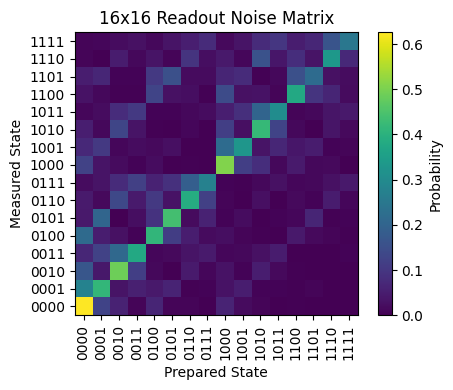

In [15]:
# STEP 7
# Plot
plot_noise_matrix(noise_matrix)

In [16]:
# ============================================================
# COMPARE:
# A_real  vs  A1⊗A2⊗A3⊗A4
# ============================================================
# REAL 16x16 MATRIX
# vs
# KRONECKER PRODUCT OF SINGLE-QUBIT MATRICES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
# BUILD INDEPENDENT MODEL
# ============================================================
def build_independent_noise_matrix(assignment_matrices):
    """ Construct:
        A_indep = A1 ⊗ A2 ⊗ A3 ⊗ A4
    from the list:
        assignment_matrices = [A1, A2, A3, A4]
    Each Ai is 2x2.   """
    A_indep = assignment_matrices[-1]
    for A in reversed(assignment_matrices[:-1]):
        A_indep = np.kron(A_indep, A)
    return A_indep
# COMPARE MATRICES
# ============================================================
def compare_noise_models(A_real, A_indep):
    Delta = A_real - A_indep
    # Metrics
    fro_norm = np.linalg.norm(Delta)
    max_abs = np.max(np.abs(Delta))
    mean_abs = np.mean(np.abs(Delta))
    print("\n================================================")
    print("COMPARISON RESULTS")
    print(f"\nFrobenius norm : {fro_norm:.6f}")
    print(f"Max abs diff   : {max_abs:.6f}")
    print(f"Mean abs diff  : {mean_abs:.6f}")
    # Diagonal comparison
    diag_real = np.diag(A_real)
    diag_indep = np.diag(A_indep)
    print("\nDiagonal fidelities (REAL):")
    print(np.round(diag_real, 4))
    print("\nDiagonal fidelities (KRONECKER MODEL):")
    print(np.round(diag_indep, 4))
    # Difference matrix
    # --------------------------------------------------------
    return Delta
# PLOT MATRIX
# ============================================================
def plot_matrix(M, title, cmap=None):
    labels = [format(i, "04b") for i in range(16)]
    plt.figure(figsize=(7,6))
    plt.imshow(M, origin="lower", cmap=cmap)
    plt.colorbar()
    plt.xticks(range(16), labels, rotation=90)
    plt.yticks(range(16),labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title(title)
    plt.tight_layout()
    plt.show()
# MAIN COMPARISON
# ============================================================
# Real matrix
A_real = noise_matrix
# Independent Kronecker model
# ------------------------------------------------------------
A_indep = build_independent_noise_matrix(assignment_matrices)
# ============================================================
# Compare
Delta = compare_noise_models( A_real, A_indep)
# # Plot real matrix
# plot_matrix(A_real,"Real 16x16 Readout Noise Matrix")
# # Plot independent model
# plot_matrix(A_indep,"Independent Kronecker Model")
# # Plot difference
# plot_matrix( Delta,"Difference Matrix: A_real - A_indep",cmap="bwr")
# ============================================================
# COLUMN NORMALIZATION CHECK
print("\n================================================")
print("COLUMN SUM CHECK")
print("\nA_real column sums:")
print(np.round(A_real.sum(axis=1), 6))
print("\nA_indep column sums:")
print(np.round(A_indep.sum(axis=1), 6))


COMPARISON RESULTS

Frobenius norm : 0.267485
Max abs diff   : 0.117124
Mean abs diff  : 0.008659

Diagonal fidelities (REAL):
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]

Diagonal fidelities (KRONECKER MODEL):
[0.5482 0.4357 0.4793 0.3809 0.4483 0.3563 0.3919 0.3115 0.4603 0.3657
 0.4024 0.3197 0.3764 0.2991 0.329  0.2615]

COLUMN SUM CHECK

A_real column sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

A_indep column sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
